🖼️ 读取 NIfTI: data/BraTS2021/TrainingData/BraTS2021_00000/BraTS2021_00000_t1.nii.gz
原始 NIfTI 形状: (240, 240, 155)
修正后形状 (D, H, W): (155, 240, 240)
原始输入尺寸: (155, 240, 240)
需要补零: D+5, H+0, W+0
Padding 后最终尺寸: (160, 240, 240)
🚀 模型推理中...
Working with z of shape (1, 4, 16, 16, 16) = 16384 dimensions.


C:\Users\qingy\AppData\Local\Temp\ipykernel_23128\1983700773.py:87: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location="cpu")


🎨 生成三视图对比...
✅ 已保存 check_orientation.png
📉 MSE Loss: 0.0028 (如果 > 0.5 说明完全没对上)


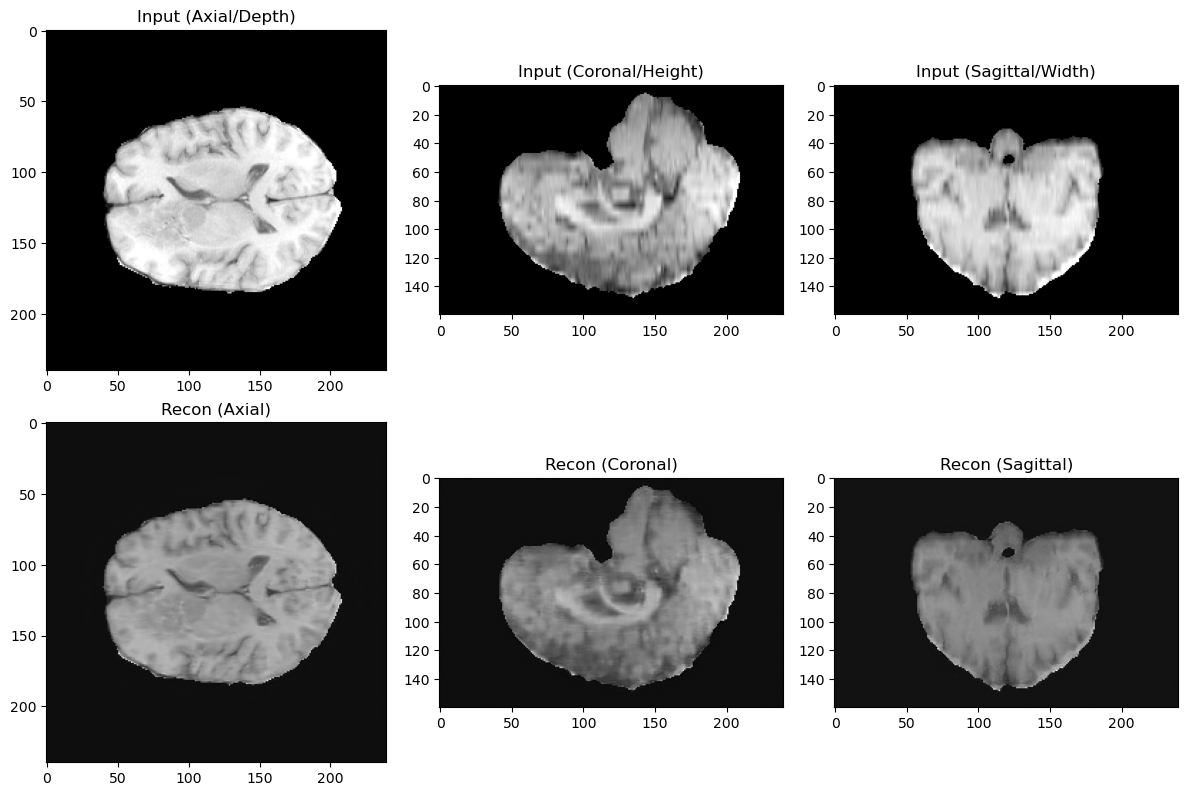

In [1]:
# 从 NIfTI 文件中读取医学图像，进行 VAE 编码再解码，并可视化结果以检查方向和对齐问题。

import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import nibabel as nib
from models.vae import AutoencoderKL

# ---------------- 配置 ----------------
# 1. 你的权重路径
CKPT_PATH = r"vqgan\stage1.ckpt" 
# 2. 随便找一个你的 BraTS 数据文件路径
TEST_IMG_PATH = r"data/BraTS2021/TrainingData/BraTS2021_00000/BraTS2021_00000_t1.nii.gz" 

DDCONFIG = {
    "double_z": False, "z_channels": 4, "resolution": 64, "in_channels": 1, "out_ch": 1, 
    "ch": 64, "num_groups": 32, "ch_mult": [1, 1, 2], "num_res_blocks": 1, 
    "attn_resolutions": [], "dropout": 0.0
}
# -------------------------------------

def check_orientation():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. 读取 NIfTI
    print(f"🖼️ 读取 NIfTI: {TEST_IMG_PATH}")
    nii = nib.load(TEST_IMG_PATH)
    img_data = nii.get_fdata() # 通常形状是 (240, 240, 155) -> (H, W, D)
    print(f"原始 NIfTI 形状: {img_data.shape}")

    # 2. 关键修正：调整维度顺序
    # PyTorch 需要 (Depth, Height, Width)
    # NIfTI 通常是 (H, W, D)。我们需要把它变成 (D, H, W) -> (2, 0, 1)
    img_data = img_data.transpose(2, 0, 1)
    print(f"修正后形状 (D, H, W): {img_data.shape}")

    # # 3. 裁剪中心区域 (确保裁剪到脑子，而不是背景)
    # # BraTS 数据脑子通常在中心
    # D, H, W = img_data.shape
    # # 强制裁剪中间的 64x64x64
    # d_s, h_s, w_s = D//2 - 32, H//2 - 32, W//2 - 32
    # img_crop = img_data[d_s:d_s+64, h_s:h_s+64, w_s:w_s+64]
    
    # ------------------ 修改开始 ------------------
    # 3. 不切片，全塞进去！
    img_slab = img_data  # 直接取全量数据 [D, H, W] (约 155, 240, 240)
    
    print(f"原始输入尺寸: {img_slab.shape}")

    # 4. 智能 Padding (必须是 16 的倍数)
    # VAE 下采样 4 次，所以边长必须能被 2^4=16 整除
    align_to = 16
    
    D, H, W = img_slab.shape
    
    # 计算每个轴需要补多少 0
    pad_d = (align_to - D % align_to) % align_to
    pad_h = (align_to - H % align_to) % align_to
    pad_w = (align_to - W % align_to) % align_to
    
    print(f"需要补零: D+{pad_d}, H+{pad_h}, W+{pad_w}")
    
    # 执行 Padding (在末尾补 0)
    if pad_d > 0 or pad_h > 0 or pad_w > 0:
        # np.pad 格式: ((前, 后), (前, 后), (前, 后))
        img_slab = np.pad(img_slab, 
                          ((0, pad_d), (0, pad_h), (0, pad_w)), 
                          mode='constant', constant_values=0)
                          
    print(f"Padding 后最终尺寸: {img_slab.shape}")
    # ------------------ 修改结束 ------------------

    # 4. 归一化 (Robust)
    lower = np.percentile(img_slab, 0.5)
    upper = np.percentile(img_slab, 99.5)
    img_norm = np.clip(img_slab, lower, upper)
    img_norm = (img_norm - lower) / (upper - lower + 1e-8)
    img_norm = img_norm * 2 - 1 # 映射到 -1 ~ 1

    # 转 Tensor: [1, 1, D, H, W]
    x = torch.from_numpy(img_norm).float().unsqueeze(0).unsqueeze(0).to(device)

    # 5. 加载模型
    print("🚀 模型推理中...")
    model = AutoencoderKL(DDCONFIG, 8192, 4)
    ckpt = torch.load(CKPT_PATH, map_location="cpu")
    sd = ckpt["state_dict"] if "state_dict" in ckpt else ckpt.get("model", ckpt)
    
    # 过滤掉 attn_1 相关 (防止之前没删干净报错，加上 strict=False)
    model.load_state_dict(sd, strict=False)
    model.to(device).eval()

    with torch.no_grad():
        quant = model.encode(x)
        recon = model.decode(quant)

    # 6. 多视角可视化 (一定要看三个面！)
    print("🎨 生成三视图对比...")
    x_np = x.cpu().numpy()[0, 0]       # [D, H, W]
    recon_np = recon.cpu().numpy()[0, 0] # [D, H, W]
    
    # 切片索引 (取中间)
    idx_d = x_np.shape[0] // 2 # 轴向 (Axial)
    idx_h = x_np.shape[1] // 2 # 冠状 (Coronal)
    idx_w = x_np.shape[2] // 2 # 矢状 (Sagittal)

    fig, axs = plt.subplots(2, 3, figsize=(12, 8))
    
    # 第一行：原图
    axs[0, 0].imshow(x_np[idx_d, :, :], cmap='gray'); axs[0, 0].set_title("Input (Axial/Depth)")
    axs[0, 1].imshow(x_np[:, idx_h, :], cmap='gray'); axs[0, 1].set_title("Input (Coronal/Height)")
    axs[0, 2].imshow(x_np[:, :, idx_w], cmap='gray'); axs[0, 2].set_title("Input (Sagittal/Width)")

    # 第二行：重建
    axs[1, 0].imshow(recon_np[idx_d, :, :], cmap='gray'); axs[1, 0].set_title("Recon (Axial)")
    axs[1, 1].imshow(recon_np[:, idx_h, :], cmap='gray'); axs[1, 1].set_title("Recon (Coronal)")
    axs[1, 2].imshow(recon_np[:, :, idx_w], cmap='gray'); axs[1, 2].set_title("Recon (Sagittal)")

    plt.tight_layout()
    plt.savefig("check_orientation.png")
    print("✅ 已保存 check_orientation.png")
    
    # 简单的数值诊断
    mse = np.mean((x_np - recon_np)**2)
    print(f"📉 MSE Loss: {mse:.4f} (如果 > 0.5 说明完全没对上)")

if __name__ == "__main__":
    check_orientation()